In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/home-credit-default-risk/bureau_balance.csv
/kaggle/input/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/home-credit-default-risk/previous_application.csv
/kaggle/input/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/home-credit-default-risk/installments_payments.csv
/kaggle/input/home-credit-default-risk/bureau.csv
/kaggle/input/home-credit-default-risk/home-credit-default-risk/sample_submission.csv
/kaggle/input/home-credit-default-risk/home-credit-default-risk/application_train.csv
/kaggle/input/home-credit-default-risk/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/home-credit-default-risk/home-credit-default-risk/application_test.csv


# Integrity & Risk Audit: Home Credit Default Risk

    This notebook inspects the Home Credit dataset to identify potential data leakage and bias **before** any model is trained.
    This notebook is diagnostic only — no modeling or fixing is done here.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [3]:
data_path = "/kaggle/input/home-credit-default-risk/home-credit-default-risk/application_train.csv"
df = pd.read_csv(data_path)

df.shape

(307511, 122)

In [4]:
df.columns[:10]


Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY'],
      dtype='object')

In [5]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

len(categorical_cols), len(numerical_cols)




(16, 106)

# Target Distribution

In [6]:
# Count target classes
target_counts = df["TARGET"].value_counts()

# Compute default rate (mean of binary target)
target_ratio = df["TARGET"].mean()

print(target_counts)
print(f"\nDefault rate: {target_ratio:.2%}")


TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


### Only ~8% defaulters means accuracy will be misleading (evaluation bias).

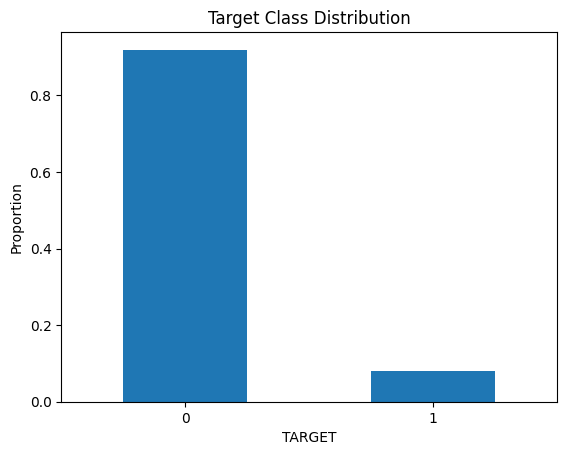

In [7]:
# Plot class proportions to visually confirm imbalance
df["TARGET"].value_counts(normalize=True).plot(
    kind="bar",
    title="Target Class Distribution",
    rot=0
)

plt.ylabel("Proportion")
plt.show()


#

# Identifier-like Columns

In [8]:
# Identify columns that look like identifiers

id_like_cols = [c for c in df.columns if "ID" in c.upper()]

id_like_cols


['SK_ID_CURR', 'DAYS_ID_PUBLISH']

### ID columns can encode system or time information (identifier leakage risk).

# Missing Value Audit

In [9]:
# Compute fraction of missing values per feature
# High missingness often indicates:
# - Process-driven data collection
# - Conditional availability of information
missing_frac = df.isnull().mean().sort_values(ascending=False)

missing_frac.head(15)


COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
dtype: float64

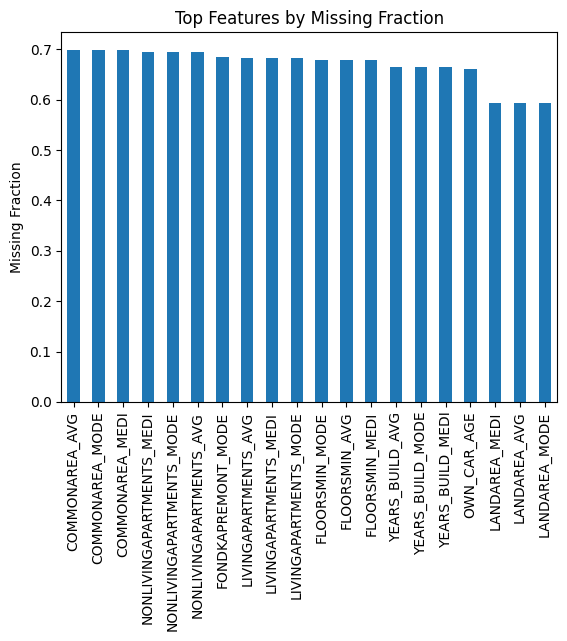

In [10]:
# Visualize top missing features
missing_frac.head(20).plot(
    kind="bar",
    title="Top Features by Missing Fraction"
)

plt.ylabel("Missing Fraction")
plt.show()


# Missingness vs Target

In [11]:
# Convert missingness to binary indicators (1 = missing)
# Then compute correlation with the target
# This checks whether the *absence* of data is predictive
missing_target_corr = (
    df.isnull()
      .astype(int)
      .corrwith(df["TARGET"])
      .sort_values(ascending=False)
)

missing_target_corr.head(10)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


EMERGENCYSTATE_MODE             0.041392
TOTALAREA_MODE                  0.041168
ENTRANCES_AVG                   0.040872
ENTRANCES_MEDI                  0.040872
ENTRANCES_MODE                  0.040872
FLOORSMAX_MODE                  0.040847
FLOORSMAX_MEDI                  0.040847
FLOORSMAX_AVG                   0.040847
YEARS_BEGINEXPLUATATION_AVG     0.040554
YEARS_BEGINEXPLUATATION_MEDI    0.040554
dtype: float64

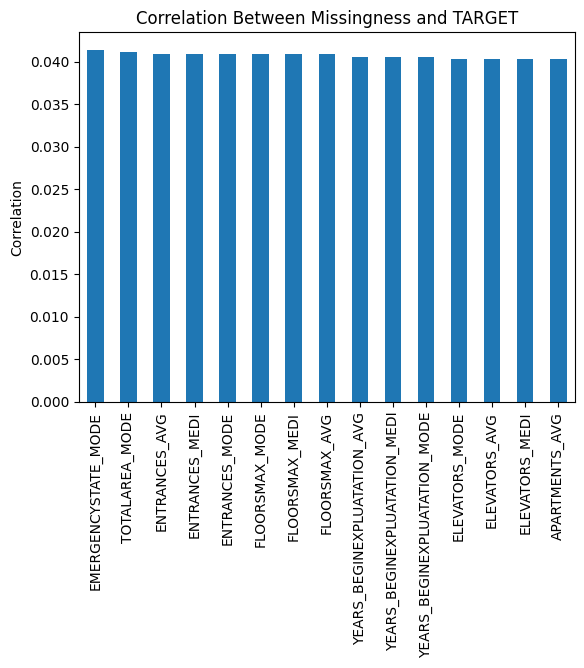

In [12]:
# Visualize strongest missingness–target correlations
missing_target_corr.head(15).plot(
    kind="bar",
    title="Correlation Between Missingness and TARGET"
)

plt.ylabel("Correlation")
plt.show()


In [13]:
# Count feature types
# Helps understand whether dataset is dominated by:
# - numeric aggregates
# - categorical descriptors
df.dtypes.value_counts()


float64    65
int64      41
object     16
Name: count, dtype: int64

# Diagnostic Train/Test Split

In [14]:
# Create a train/holdout split for diagnostic analysis
# IMPORTANT:
# - This split is NOT used for modeling
# - No preprocessing statistics are reused later
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Correlation with Target (Train Only)

In [15]:
# Compute correlations with TARGET using TRAIN DATA ONLY
# Using full data here would cause design-decision leakage
train_corr = (
    pd.concat([X_train, y_train], axis=1)
    .corr(numeric_only=True)["TARGET"]
    .sort_values(ascending=False)
)

train_corr.head(15)


TARGET                         1.000000
DAYS_BIRTH                     0.079467
REGION_RATING_CLIENT_W_CITY    0.061283
REGION_RATING_CLIENT           0.058946
DAYS_LAST_PHONE_CHANGE         0.053795
REG_CITY_NOT_WORK_CITY         0.051666
DAYS_ID_PUBLISH                0.049582
FLAG_EMP_PHONE                 0.046407
REG_CITY_NOT_LIVE_CITY         0.045654
FLAG_DOCUMENT_3                0.044299
DAYS_REGISTRATION              0.042127
OWN_CAR_AGE                    0.038289
LIVE_CITY_NOT_WORK_CITY        0.033339
DEF_60_CNT_SOCIAL_CIRCLE       0.032074
DEF_30_CNT_SOCIAL_CIRCLE       0.032059
Name: TARGET, dtype: float64

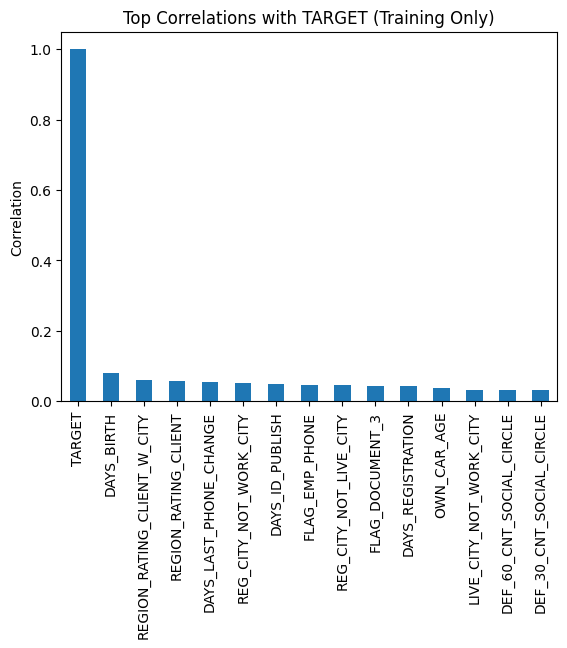

In [16]:
# Visualize top correlations
train_corr.head(15).plot(
    kind="bar",
    title="Top Correlations with TARGET (Training Only)"
)

plt.ylabel("Correlation")
plt.show()


# Legitimate Strong Predictors

In [17]:
# Identify well-known legitimate predictors
# EXT_SOURCE variables are external risk scores available at application time
legitimate_features = [c for c in train_corr.index if "EXT_SOURCE" in c]

legitimate_features


['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Temporal Feature Audit

In [18]:
# Identify time-like variables
# These may encode relative or absolute time information
time_like_cols = [c for c in df.columns if "DAYS" in c or "DATE" in c]

time_like_cols[:10]


['DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'DAYS_LAST_PHONE_CHANGE']

### No true timestamp exists, creating temporal leakage risk.

### *There is NO extremely high correlation with TARGET.*
* Target leakage here will be semantic or temporal, not statistical.

## Feature Availability Audit

For each feature, we ask:
- Would this information be available at loan application time?
- Or does it become known only after loan approval or repayment begins?

Features related to payments, balances, or outcomes pose a high risk of target leakage.


## Temporal Risk Assessment

Credit default is a time-dependent outcome.
Using random train-test splits may introduce temporal leakage,
as future loans could influence past predictions.


## Integrity Audit Summary

- Severe class imbalance → evaluation bias  
- ID-like features → identifier leakage risk  
- Time proxies → temporal leakage risk  
- High missingness → process bias  
- Missingness predicts target → workflow bias  
- Engineered numeric features → feature leakage risk  
- Correlations reasonable → no raw-data leakage  
- EXT_SOURCE features → legitimate predictors  
- No true timestamp → temporal ambiguity  
- Competition-curated data → sampling / collider bias  

**Conclusion:**  
Leakage is not present directly in the raw data, but can easily be introduced
through preprocessing, feature selection, and evaluation choices.

